<a href="https://colab.research.google.com/github/golitos/deteccao-fraudes-dio/blob/colab/deteccao_fraudes_dio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Detecção de Fraudes em Transações Financeiras
> **Curso:** BootCamp Bradesco - GenAI, Dados & Cyber

---

## 📌 Visão Geral do Projeto
Este projeto aborda o problema clássico de detecção de fraudes em cartões de crédito utilizando o conhecido dataset com transações reais de titulares europeus. O objetivo principal é identificar transações fraudulentas minimizando os falsos negativos (fraudes não detectadas).

### 🛠️ Tecnologias Utilizadas
* **Linguagem:** Python
* **Manipulação e Análise de Dados:** `pandas`, `numpy`
* **Visualização:** `matplotlib`, `seaborn`
* **Machine Learning:** `scikit-learn` (Pre-processing, Model Selection, Metrics, Linear Models)

---

## ⚙️ Metodologia e Solução

1. **Análise de Dados Desbalanceados:**
   O dataset original apresenta um desbalanceamento extremo de classes ($~0.17\%$ de fraudes). Para contornar esse problema e evitar que o modelo ignore a classe minoritária, utilizamos o parâmetro `class_weight='balanced'` no algoritmo de Regressão Logística.

2. **Feature Engineering & Pré-processamento:**
   * Separação de dados em treino e teste ($80/20$) de forma **estratificada** (`stratify=y`), mantendo a proporção de fraudes em ambos os conjuntos.
   * Padronização das variáveis numéricas (`Time`, `Amount` e variáveis latentes `V1-V28`) utilizando `StandardScaler` para garantir convergência rápida e justa do modelo linear.

3. **Métricas de Avaliação Críticas:**
   Em problemas de fraude, a acurácia global é uma métrica enganosa. Por isso, a performance foi avaliada com base em:
   * **Recall (Sensibilidade):** Capacidade de detectar o maior número de fraudes possível.
   * **F1-Score:** Equilíbrio entre Precisão e Recall.
   * **Curva ROC-AUC ($AUC$):** Avaliação geral do poder discriminatório do modelo.

---

## 🚀 Como Rodar o Notebook
1. Execute a primeira célula para importar as dependências.
2. Na **Célula 2**, insira a URL do seu arquivo CSV na variável `URL_CSV`.
   * *Nota: Caso a URL seja mantida vazia, o notebook gerará automaticamente um dataset sintético desbalanceado de 10.000 linhas com a mesma estrutura de colunas para fins de teste funcional.*
3. Execute as células sequencialmente para visualizar as análises gráficas, realizar o treinamento e conferir as métricas de avaliação.

# Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pré-processamento e divisão dos Dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# modelo de classificação
from sklearn.linear_model import LogisticRegression

# métricas de avaliação
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                              roc_auc_score, precision_recall_curve)

# configurações estéticas dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#Carregamento dos Dados (com URL ou Dataset de Teste)

In [ ]:

URL_CSV = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

if URL_CSV.strip() != "":
    print("📥 Carregando os dados a partir da URL fornecida...")
    df = pd.read_csv(URL_CSV)
else:
    print("⚠️ Nenhuma URL fornecida. Gerando dataset sintético idêntico ao original para teste...")
    np.random.seed(42)
    n_samples = 10000

    # Criando colunas V1 a V28 fictícias
    data = {f'V{i}': np.random.normal(0, 1, n_samples) for i in range(1, 29)}

    # Adicionando Time, Amount e Class
    data['Time'] = np.arange(n_samples)
    data['Amount'] = np.random.exponential(50, n_samples)

    # Probabilidade de fraude baseada em algumas variáveis fictícias
    prob = 1 / (1 + np.exp(-( -5 + 0.5 * data['V1'] - 0.8 * data['V2'] + 0.005 * data['Amount'] )))
    data['Class'] = np.random.binomial(1, prob)

    df = pd.DataFrame(data)

# Visualizando as primeiras linhas e informações básicas do DataFrame
print(f"\nDimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())
df.info()

📥 Carregando os dados a partir da URL fornecida...

Dimensões do dataset: 284807 linhas e 31 colunas.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#Análise Exploratória (Gráficos)

/tmp/ipykernel_1665/261002165.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


Transações Legítimas: 284315 (99.8273%)
Transações Fraudulentas: 492 (0.1727%)


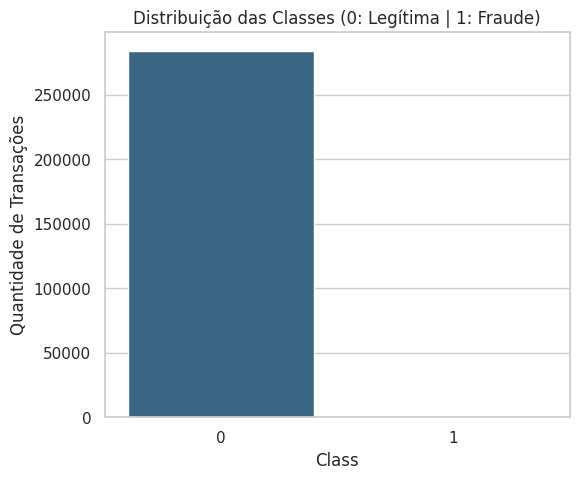

/tmp/ipykernel_1665/261002165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')


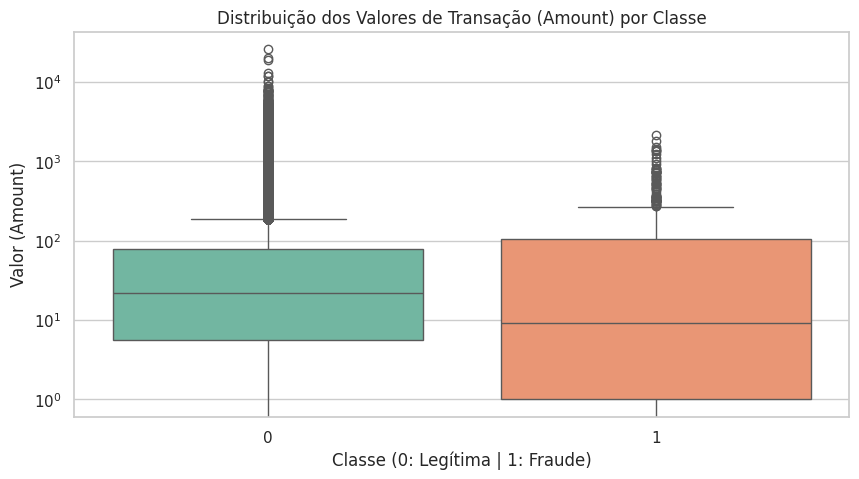

In [ ]:
# 1. distribuição da variável alvo (Class)
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribuição das Classes (0: Legítima | 1: Fraude)')
plt.xlabel('Class')
plt.ylabel('Quantidade de Transações')

# calculando as porcentagens
total = len(df)
fraudes = df[df['Class'] == 1].shape[0]
legitimas = df[df['Class'] == 0].shape[0]
print(f"Transações Legítimas: {legitimas} ({legitimas/total*100:.4f}%)")
print(f"Transações Fraudulentas: {fraudes} ({fraudes/total*100:.4f}%)")
plt.show()

# 2. distribuição do Valor das Transações por Classe
plt.figure(figsize=(10, 5))
sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')
plt.title('Distribuição dos Valores de Transação (Amount) por Classe')
plt.xlabel('Classe (0: Legítima | 1: Fraude)')
plt.ylabel('Valor (Amount)')
plt.yscale('log') # Escala logarítmica devido aos outliers do dataset real
plt.show()

#Feature Engineering e Pré-processamento

In [ ]:
# identificando a coluna alvo e as variáveis preditoras usando a nomenclatura exata
target_col = 'Class'
features = [col for col in df.columns if col != target_col]

X = df[features]
y = df[target_col]

# dividindo os dados em conjuntos de Treino e Teste (estratificado devido ao desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# padronização de todas as features preditoras (V1-V28, Time, Amount)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados pré-processados e divididos com sucesso!")
print(f"Treino: {X_train_scaled.shape[0]} amostras | Teste: {X_test_scaled.shape[0]} amostras")

Dados pré-processados e divididos com sucesso!
Treino: 227845 amostras | Teste: 56962 amostras


#Regressão Logarítmica

In [ ]:
# instanciando o modelo tratando o desbalanceamento de classes diretamente
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# treinando o modelo nos dados de treino padronizados
model.fit(X_train_scaled, y_train)

# fazendo previsões de classe (0 ou 1)
y_pred = model.predict(X_test_scaled)

# obtendo as probabilidades das previsões (necessário para a curva ROC)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


#Avaliação e Métricas

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



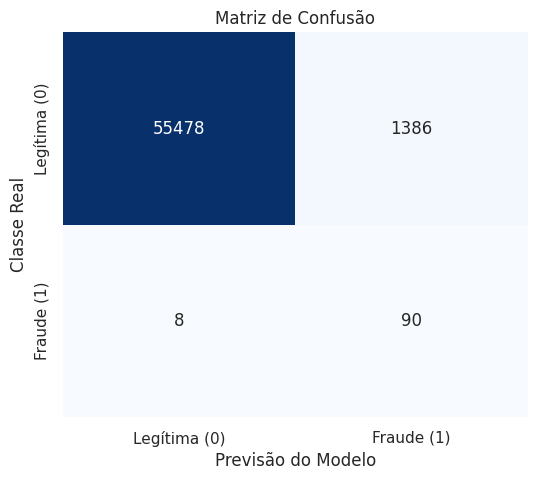

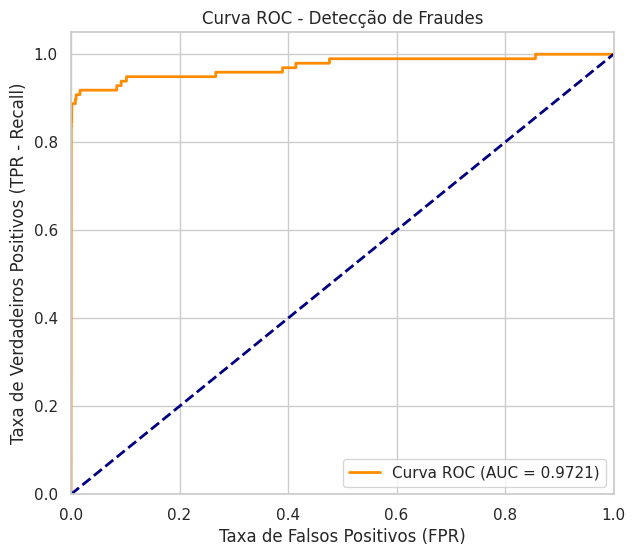

In [ ]:
# 1. eExibindo relatório de classificação
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

# 2. plot da matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legítima (0)', 'Fraude (1)'],
            yticklabels=['Legítima (0)', 'Fraude (1)'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.show()

# 3. plotando da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)')
plt.title('Curva ROC - Detecção de Fraudes')
plt.legend(loc="lower right")
plt.show()